In [21]:
import chess
import torch

# Detecta GPU automaticamente; todos os tensores serão movidos para este device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

# Ordem fixa: brancas (P N B R Q K) nas camadas 0-5, pretas (p n b r q k) nas camadas 6-11
PIECE_TYPES = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]

def board_to_tensor(board: chess.Board) -> torch.Tensor:
    """
    Converte um chess.Board em um tensor (12, 8, 8) pronto para GPU.
    Camadas 0-5  → peças brancas (P, N, B, R, Q, K)
    Camadas 6-11 → peças pretas  (p, n, b, r, q, k)
    Valor 1.0 onde a peça está presente, 0.0 caso contrário.
    """
    tensor = torch.zeros(12, 8, 8, dtype=torch.float32)

    for color_idx, color in enumerate([chess.WHITE, chess.BLACK]):
        for piece_idx, piece_type in enumerate(PIECE_TYPES):
            layer = color_idx * 6 + piece_idx
            for square in board.pieces(piece_type, color):
                row = chess.square_rank(square)  # 0 = rank 1, 7 = rank 8
                col = chess.square_file(square)  # 0 = file a, 7 = file h
                tensor[layer, row, col] = 1.0

    return tensor.to(device)


# --- Teste rápido ---
board = chess.Board()  # posição inicial
t = board_to_tensor(board)
print(f"Shape : {t.shape}")   # esperado: torch.Size([12, 8, 8])
print(f"Device: {t.device}")  # esperado: cuda:0  (ou cpu se não houver GPU)
print(f"Peões brancos (camada 0):\n{t[0]}")   # linha 1 (rank 2) deve ser tudo 1s
print(f"Peões pretos  (camada 6):\n{t[6]}")   # linha 6 (rank 7) deve ser tudo 1s


Usando device: cuda
Shape : torch.Size([12, 8, 8])
Device: cuda:0
Peões brancos (camada 0):
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')
Peões pretos  (camada 6):
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [0., 0., 0., 0., 0., 0., 0., 0.]], device='cuda:0')


In [22]:
import torch.nn as nn
from pathlib import Path

# ── ResidualBlock — idêntico ao projeto anterior ──────────────────────────────
class ResidualBlock(nn.Module):
    """
    Duas Conv2d 3x3 (padding=1, stride=1 → preserva 8x8) com BatchNorm e
    skip connection. Projeção 1x1 automática quando in_channels != out_channels.
    """
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.dropout  = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.shortcut = (
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


# ── ChessResNetDQN ────────────────────────────────────────────────────────────
class ChessResNetDQN(nn.Module):
    """
    Backbone ResNet (mesmo do projeto anterior) + cabeça de Q-value para DQN.

    Entrada : (batch, 12, 8, 8) — saída de board_to_tensor()
    Saída   : (batch,)          — Q-value escalar por estado

    Diferença em relação ao ChessEvalResNet supervisionado:
      · in_channels=12 em vez de 15 (sem os canais de turno e roque)
      · Módulo da cabeça mantém o nome "head" para maximizar o warm start
        (as chaves do state_dict batem com o checkpoint treinado)
    """
    def __init__(
        self,
        in_channels    = 12,
        stem_channels  = 64,
        block_channels = (64, 128, 128, 256),
        hidden_dim     = 256,
        dropout        = 0.3,
    ):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, stem_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.ReLU(inplace=True),
        )

        blocks, prev = [], stem_channels
        for out_ch in block_channels:
            blocks.append(ResidualBlock(prev, out_ch, dropout=dropout * 0.5))
            prev = out_ch
        self.res_blocks = nn.Sequential(*blocks)

        self.gap = nn.AdaptiveAvgPool2d(1)  # (C, 8, 8) → (C, 1, 1)

        # Nome "head" propositalmente idêntico ao projeto anterior
        # para que os pesos carreguem direto do checkpoint
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(prev, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),  # Q-value escalar
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.res_blocks(x)
        x = self.gap(x)
        return self.head(x).squeeze(-1)   # (batch, 1) → (batch,)


# ── Warm Start ────────────────────────────────────────────────────────────────
CHECKPOINT = Path("best_model_resnet.pt")

dqn_net = ChessResNetDQN(in_channels=12).to(device)

pretrained_sd = torch.load(CHECKPOINT, map_location=device, weights_only=True)
model_sd      = dqn_net.state_dict()

# Filtra chaves com shape incompatível antes de chamar load_state_dict.
# strict=False sozinho ignora chaves ausentes/extras, mas ainda lança erro
# em mismatches de shape — por isso o filtro manual é necessário aqui.
compatible   = {k: v for k, v in pretrained_sd.items()
                if k in model_sd and v.shape == model_sd[k].shape}
incompatible = [k for k in pretrained_sd if k not in compatible]

dqn_net.load_state_dict(compatible, strict=False)

# ── Relatório de carregamento ─────────────────────────────────────────────────
total_params = sum(p.numel() for p in dqn_net.parameters())
cold_params  = sum(
    p.numel() for name, p in dqn_net.named_parameters()
    if any(name.startswith(k.split(".")[0]) and name in
           {k2 for k2 in model_sd if k2 not in compatible}
           for k in incompatible)
)
# Conta parâmetros cold via nomes excluídos do compatible
cold_names = {k for k in model_sd if k not in compatible}
cold_params = sum(p.numel() for name, p in dqn_net.named_parameters()
                  if name in cold_names)
warm_params = total_params - cold_params

print("=== Warm Start — Relatório ===")
print(f"Checkpoint       : {CHECKPOINT}")
print(f"Chaves carregadas: {len(compatible)}/{len(pretrained_sd)}")
if incompatible:
    print(f"Shape incompatível (reinicializados): {incompatible}")
print(f"\nParâmetros totais    : {total_params:,}")
print(f"  Warm-started       : {warm_params:,}  ({100*warm_params/total_params:.1f}%)")
print(f"  Reinicializados    : {cold_params:,}  ({100*cold_params/total_params:.1f}%)")

# Sugestão: congele o backbone nas primeiras épocas de RL para estabilizar
# o treino — o stem reinicializado ainda está ruidoso nesse momento.
# Descomente se quiser esse comportamento:
# for name, param in dqn_net.named_parameters():
#     if not name.startswith("head"):
#         param.requires_grad = False

dqn_net.train()   # modo treino para as camadas Dropout/BN
print(f"\n{dqn_net}")
n_treinaveis = sum(p.numel() for p in dqn_net.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_treinaveis:,}")


=== Warm Start — Relatório ===
Checkpoint       : best_model_resnet.pt
Chaves carregadas: 71/72
Shape incompatível (reinicializados): ['stem.0.weight']

Parâmetros totais    : 1,624,449
  Warm-started       : 1,617,537  (99.6%)
  Reinicializados    : 6,912  (0.4%)

ChessResNetDQN(
  (stem): Sequential(
    (0): Conv2d(12, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (dropout): Dropout2d(p=0.

### 3. Loop de Treinamento — Expert Iteration com Minimax

Com a arquitetura definida, passo ao **treinamento por Aprendizado por Reforço** em uma formulação de **Expert Iteration**: o modelo joga contra si mesmo (*self-play*) mas, em vez de selecionar lances diretamente pela saída da rede, usa uma **busca Minimax com poda Alfa-Beta de profundidade 2** para calcular táticas básicas antes de agir. A ResNet funciona como a função de avaliação das posições folha dessa árvore — combinando o aprendizado representacional das redes neurais com a força tática da busca clássica.

Essa formulação endereça diretamente os dois problemas observados no DQN puro:
- **Empates por repetição** surgem porque a rede aprende a evitar a derrota sem aprender a forçar vitórias. O Minimax com profundidade 2 já enxerga a resposta adversária imediata e descarta lances que levam a posições perdedoras no próximo turno;
- **Aberturas sem sentido** ocorrem quando o modelo gasta dezenas de lances em variações aleatórias de pouco valor tático. O filtro de posições iniciais (10 aberturas clássicas em FEN) faz o self-play começar diretamente em posições ricas de meio-jogo, concentrando o orçamento de 14h de GPU onde o aprendizado é mais denso.

#### 3.1 Hiperparâmetros e Componentes

In [23]:
import random
from collections import deque
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from tqdm.auto import tqdm

# ── Hiperparâmetros ────────────────────────────────────────────────────────────
N_GAMES          = 4_000   # total de partidas de self-play
MAX_PLIES        = 400     # limite de meios-lances por partida (200 lances completos)
GAMMA            = 0.99    # fator de desconto temporal
EPSILON_START    = 1.0     # exploração inicial (100% aleatório)
EPSILON_END      = 0.05    # piso de exploração
EPSILON_DECAY    = 0.9990  # fator multiplicativo por partida — atinge 0.05 ~game 3000
LR               = 1e-4
BATCH_SIZE       = 64
BUFFER_CAPACITY  = 50_000  # capacidade máxima do replay buffer
MIN_BUFFER       = 2_000   # aguarda N transições antes de começar o treino
TARGET_UPDATE    = 100     # copia pesos para a target net a cada N partidas
CHECKPOINT_EVERY = 1000     # salva checkpoint a cada N partidas
CHECKPOINT_DIR   = Path("dqn_checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)


# ── Replay Buffer ──────────────────────────────────────────────────────────────
class ReplayBuffer:
    """Buffer circular de tamanho fixo. Transições salvas na CPU para não saturar VRAM."""

    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    def push(self, state: torch.Tensor, next_state: torch.Tensor,
             reward: float, done: bool):
        self.buffer.append((state.cpu(), next_state.cpu(), float(reward), float(done)))

    def sample(self, batch_size: int):
        batch                              = random.sample(self.buffer, batch_size)
        states, next_states, rewards, dones = zip(*batch)
        return (
            torch.stack(states).to(device),
            torch.stack(next_states).to(device),
            torch.tensor(rewards, dtype=torch.float32, device=device),
            torch.tensor(dones,   dtype=torch.float32, device=device),
        )

    def __len__(self):
        return len(self.buffer)


# ── Componentes de treino ──────────────────────────────────────────────────────
replay_buffer = ReplayBuffer(BUFFER_CAPACITY)
epsilon       = EPSILON_START

# Target network: cópia congelada da rede principal para estabilizar o alvo Bellman
target_net = ChessResNetDQN(in_channels=12).to(device)
target_net.load_state_dict(dqn_net.state_dict())
target_net.eval()

optimizer_rl = torch.optim.Adam(dqn_net.parameters(), lr=LR)

print("Setup concluído.")
print(f"  Partidas      : {N_GAMES:,}")
print(f"  Epsilon       : {EPSILON_START} → {EPSILON_END}  (decay={EPSILON_DECAY})")
print(f"  Replay buffer : capacidade {BUFFER_CAPACITY:,}  |  treino começa em {MIN_BUFFER:,} transições")
print(f"  Target update : a cada {TARGET_UPDATE} partidas")
print(f"  Checkpoints   : {CHECKPOINT_DIR}/  (a cada {CHECKPOINT_EVERY} partidas)")


Setup concluído.
  Partidas      : 4,000
  Epsilon       : 1.0 → 0.05  (decay=0.999)
  Replay buffer : capacidade 50,000  |  treino começa em 2,000 transições
  Target update : a cada 100 partidas
  Checkpoints   : dqn_checkpoints/  (a cada 1000 partidas)


#### 3.2 Expert Iteration — Minimax, Aberturas, Reward Shaping e Critério de Tempo

**Busca Minimax com Poda Alfa-Beta (profundidade 2).** A seleção de lances na fase de explotação deixa de ser um forward pass direto e passa a ser uma busca em árvore:

$$\text{lance}^* = \arg\max_{a} \; V_{\text{minimax}}(s', \text{depth}=1)$$

onde $V_{\text{minimax}}$ alterna entre maximização (brancas) e minimização (pretas) e usa a ResNet como $V(s)$ nas posições folha. Com profundidade 2, o agente considera o seu lance mais a resposta ótima do adversário — suficiente para calcular capturas simples, ameaças diretas e evitar trocas desvantajosas.

**Warm Start de Posições (aberturas famosas).** Em vez de partir sempre da posição inicial, cada partida começa em uma das 10 aberturas clássicas sorteadas aleatoriamente (Siciliana Najdorf, Ruy Lopez, Francesa, Gambito da Dama, Caro-Kann, Italiana, London System, Pirc e outras). Isso garante que o replay buffer seja preenchido com transições de meio-jogo variadas, onde a diferença entre lances bons e ruins é mais pronunciada.

**Reward Shaping agressivo.** A recompensa total por transição combina três componentes:

$$r_{\text{total}} = r_{\text{material}}(t) + r_{\text{terminal}}$$

| Evento | Recompensa |
|--------|-----------|
| Captura de peão | $+1$ (brancas) / $-1$ (pretas) |
| Captura de cavalo ou bispo | $\pm 3$ |
| Captura de torre | $\pm 5$ |
| Captura de dama | $\pm 9$ |
| Xeque-mate | $+10$ (brancas) / $-10$ (pretas) |
| Empate com $\geq 80$ plies (40 lances) | $0$ |
| **Empate com $< 80$ plies** | $\mathbf{-5}$ **(penalidade por empate rápido)** |

A penalidade de $-5$ para empates precoces é o mecanismo central para eliminar a convergência para "empates bobos": qualquer estado que leve a um empate com menos de 40 lances completos é tratado como uma derrota parcial para ambos os lados, forçando a rede a preferir continuar jogando em posições equilibradas.

**Critério de parada por tempo.** O loop verifica `time.time()` no início de cada partida e quebra automaticamente se o tempo decorrido atingir **13h30m** — deixando 30 minutos de margem dentro do orçamento de 14h para o salvamento seguro do checkpoint final e encerramento do TensorBoard.

#### 3.3 Loop Principal de Self-Play

In [24]:
import time

# ══════════════════════════════════════════════════════════════════════════════
# ── Constantes do Expert Iteration ────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

MAX_TRAINING_SECONDS = int(13.5 * 3600)  # critério de parada: 13h30m
MINIMAX_DEPTH        = 2                 # plies da busca Minimax
DRAW_PENALTY_PLIES   = 80               # empates abaixo disto são punidos (40 lances)
DRAW_PENALTY         = -5.0             # penalidade para empates rápidos

# FENs verificadas manualmente — 10 aberturas clássicas para warm start de posições
OPENING_FENS = [
    "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1",           # posição inicial
    "rnbqkbnr/pp1ppppp/8/2p5/4P3/8/PPPP1PPP/RNBQKBNR w KQkq c6 0 2",      # Siciliana (1.e4 c5)
    "rnbqkb1r/1p2pppp/p2p1n2/8/3NP3/2N5/PPP2PPP/R1BQKB1R w KQkq - 0 6",  # Siciliana Najdorf
    "r1bqkbnr/pppp1ppp/2n5/1B2p3/4P3/5N2/PPPP1PPP/RNBQK2R b KQkq - 3 3",  # Ruy Lopez
    "rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 0 3",      # Francesa
    "rnbqkbnr/ppp1pppp/8/3p4/2PP4/8/PP2PPPP/RNBQKBNR b KQkq - 0 2",       # Gambito da Dama
    "rnbqkbnr/pp2pppp/2p5/3p4/3PP3/8/PPP2PPP/RNBQKBNR w KQkq - 0 3",      # Caro-Kann
    "r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5N2/PPPP1PPP/RNBQK2R b KQkq - 3 3",  # Italiana
    "rnbqkb1r/ppp1pppp/5n2/3p4/3P1B2/5N2/PPP1PPPP/RN1QKB1R b KQkq - 3 3", # London System
    "rnbqkb1r/ppp1pp1p/3p1np1/8/3PP3/2N5/PPP2PPP/R1BQKBNR w KQkq - 0 4",  # Pirc/Moderna
]

# ── Material ───────────────────────────────────────────────────────────────────
MATERIAL_VALUES = {
    chess.PAWN:   1, chess.KNIGHT: 3, chess.BISHOP: 3,
    chess.ROOK:   5, chess.QUEEN:  9, chess.KING:   0,
}

def material_score(board: chess.Board) -> float:
    """Saldo de material do ponto de vista das brancas (positivo = vantagem branca)."""
    score = 0.0
    for piece in board.piece_map().values():
        v = MATERIAL_VALUES[piece.piece_type]
        score += v if piece.color == chess.WHITE else -v
    return score


# ── Minimax com Poda Alfa-Beta ─────────────────────────────────────────────────

def _alphabeta(board: chess.Board, depth: int,
               alpha: float, beta: float,
               maximizing: bool, model: nn.Module) -> float:
    """
    Minimax recursivo com poda alfa-beta.
    Folhas (depth=0) e posições terminais são avaliadas pela ResNet.
    """
    if board.is_game_over():
        r = board.result()
        return 10.0 if r == "1-0" else (-10.0 if r == "0-1" else 0.0)
    if depth == 0:
        return model(board_to_tensor(board).unsqueeze(0)).item()

    moves = list(board.legal_moves)
    if maximizing:
        val = -float("inf")
        for mv in moves:
            board.push(mv)
            val = max(val, _alphabeta(board, depth - 1, alpha, beta, False, model))
            board.pop()
            alpha = max(alpha, val)
            if alpha >= beta:   # poda beta
                break
        return val
    else:
        val = float("inf")
        for mv in moves:
            board.push(mv)
            val = min(val, _alphabeta(board, depth - 1, alpha, beta, True, model))
            board.pop()
            beta = min(beta, val)
            if alpha >= beta:   # poda alfa
                break
        return val


@torch.no_grad()
def select_action(board: chess.Board, eps: float, model: nn.Module) -> chess.Move:
    """
    Epsilon-greedy com Minimax+Alfa-Beta de profundidade MINIMAX_DEPTH.
    · Exploração (prob. ε) : lance aleatório.
    · Explotação           : busca em árvore com a ResNet nas folhas.
      Brancas maximizam Q, Pretas minimizam — perspectiva fixa das brancas.
    """
    legal = list(board.legal_moves)
    if not legal:
        return None
    if random.random() < eps:
        return random.choice(legal)

    is_white     = (board.turn == chess.WHITE)
    was_training = model.training
    model.eval()

    best_move = legal[0]
    best_val  = -float("inf") if is_white else float("inf")

    for mv in legal:
        board.push(mv)
        # Chama alpha-beta para o nível seguinte (resposta do adversário)
        val = _alphabeta(board, MINIMAX_DEPTH - 1,
                         -float("inf"), float("inf"),
                         not is_white, model)
        board.pop()
        if (is_white and val > best_val) or (not is_white and val < best_val):
            best_val, best_move = val, mv

    if was_training:
        model.train()

    return best_move


def train_step() -> tuple:
    """Passo de gradiente DQN com target network. Alvo Bellman: r + γ·Q_frozen(s')."""
    if len(replay_buffer) < MIN_BUFFER:
        return None, None

    dqn_net.train()
    states, next_states, rewards, dones = replay_buffer.sample(BATCH_SIZE)
    current_q = dqn_net(states)

    with torch.no_grad():
        target_q = rewards + GAMMA * (1.0 - dones) * target_net(next_states)

    loss = F.mse_loss(current_q, target_q)
    optimizer_rl.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(dqn_net.parameters(), max_norm=1.0)
    optimizer_rl.step()

    return loss.item(), current_q.mean().item()


print("Funções definidas: material_score | _alphabeta | select_action (minimax) | train_step")
print(f"  Minimax depth        = {MINIMAX_DEPTH} plies")
print(f"  Aberturas disponíveis= {len(OPENING_FENS)} posições")
print(f"  Limite de tempo      = {MAX_TRAINING_SECONDS/3600:.1f}h")
print(f"  Penalidade de empate = {DRAW_PENALTY}  (abaixo de {DRAW_PENALTY_PLIES} plies)")


# ══════════════════════════════════════════════════════════════════════════════
# ── Loop Principal — Expert Iteration por Self-Play ────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

LOG_DIR = f"runs/chess_expertiter_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer  = SummaryWriter(log_dir=LOG_DIR)
print(f"\nTensorBoard: tensorboard --logdir {LOG_DIR}\n")

game_idx     = 0           # inicializado antes do loop para referência segura no finally
global_step  = 0
epsilon      = EPSILON_START
start_time   = time.time()
time_stopped = False

try:
    pbar = tqdm(range(1, N_GAMES + 1), desc="Expert Iter / Self-play", unit="partida")

    for game_idx in pbar:

        # ── Critério de parada por tempo (verificado a cada partida) ──────
        elapsed = time.time() - start_time
        if elapsed >= MAX_TRAINING_SECONDS:
            tqdm.write(
                f"\nLimite de {MAX_TRAINING_SECONDS / 3600:.1f}h atingido "
                f"após {elapsed / 3600:.2f}h — interrompendo o loop."
            )
            time_stopped = True
            break

        # ── Warm start de posições: abertura sorteada aleatoriamente ──────
        board = chess.Board(random.choice(OPENING_FENS))

        game_loss     = []
        game_qvals    = []
        game_captures = 0   # total de capturas — proxy de agressividade tática

        # ── Self-play com busca Minimax depth-2 ───────────────────────────
        while not board.is_game_over() and len(board.move_stack) < MAX_PLIES:

            state      = board_to_tensor(board)
            mat_before = material_score(board)

            move = select_action(board, epsilon, dqn_net)
            board.push(move)
            next_state = board_to_tensor(board)

            # ── Reward: variação de material + terminal (com penalidade) ──
            mat_after  = material_score(board)
            r_material = mat_after - mat_before
            if abs(r_material) > 0:
                game_captures += 1

            done       = board.is_game_over() or (len(board.move_stack) >= MAX_PLIES)
            r_terminal = 0.0
            if board.is_game_over():
                result = board.result()
                if result == "1-0":
                    r_terminal = 10.0
                elif result == "0-1":
                    r_terminal = -10.0
                else:
                    # Empate rápido → penalidade; empate longo → neutro
                    r_terminal = DRAW_PENALTY if len(board.move_stack) < DRAW_PENALTY_PLIES else 0.0

            replay_buffer.push(state, next_state, r_material + r_terminal, done)

            # Passo de treino após cada transição
            loss_val, q_mean = train_step()
            if loss_val is not None:
                game_loss.append(loss_val)
                game_qvals.append(q_mean)
                writer.add_scalar("Train/Loss",         loss_val, global_step)
                writer.add_scalar("Train/Mean_Q_Value", q_mean,   global_step)
                global_step += 1

        # ── Fim de partida ─────────────────────────────────────────────────
        result_str  = board.result() if board.is_game_over() else "1/2-1/2"
        game_length = len(board.move_stack)
        elapsed_h   = (time.time() - start_time) / 3600
        epsilon     = max(EPSILON_END, epsilon * EPSILON_DECAY)

        # ── TensorBoard: métricas por partida ─────────────────────────────
        writer.add_scalar("Game/Epsilon",        epsilon,       game_idx)
        writer.add_scalar("Game/Length_Plies",   game_length,   game_idx)
        writer.add_scalar("Game/Capturas_Total", game_captures, game_idx)
        writer.add_scalar("Game/Tempo_Horas",    elapsed_h,     game_idx)
        writer.add_scalars(
            "Game/Resultado",
            {
                "Brancas_vencem": float(result_str == "1-0"),
                "Pretas_vencem":  float(result_str == "0-1"),
                "Empate":         float(result_str not in ("1-0", "0-1")),
            },
            game_idx,
        )
        if game_loss:
            writer.add_scalar("Game/Avg_Loss",    sum(game_loss)  / len(game_loss),  game_idx)
            writer.add_scalar("Game/Avg_Q_Value", sum(game_qvals) / len(game_qvals), game_idx)

        # ── Target network (hard update) ───────────────────────────────────
        if game_idx % TARGET_UPDATE == 0:
            target_net.load_state_dict(dqn_net.state_dict())

        # ── Checkpoint periódico ────────────────────────────────────────────
        if game_idx % CHECKPOINT_EVERY == 0:
            ckpt = CHECKPOINT_DIR / f"dqn_{game_idx:05d}.pt"
            torch.save({
                "game":        game_idx,
                "model":       dqn_net.state_dict(),
                "optimizer":   optimizer_rl.state_dict(),
                "epsilon":     epsilon,
                "global_step": global_step,
                "elapsed_h":   elapsed_h,
            }, ckpt)
            tqdm.write(f"  [Checkpoint] {ckpt}  ({elapsed_h:.2f}h decorridas)")

        pbar.set_postfix(
            eps      = f"{epsilon:.4f}",
            result   = result_str,
            plies    = game_length,
            captures = game_captures,
            loss     = f"{game_loss[-1]:.4f}" if game_loss else "N/A",
            t        = f"{elapsed_h:.1f}h",
        )

except KeyboardInterrupt:
    print("\nTreino interrompido pelo usuário.")

finally:
    # Salva checkpoint final de forma segura em qualquer cenário de encerramento
    elapsed_h  = (time.time() - start_time) / 3600
    final_ckpt = CHECKPOINT_DIR / "dqn_final.pt"
    torch.save({
        "game":        game_idx,
        "model":       dqn_net.state_dict(),
        "optimizer":   optimizer_rl.state_dict(),
        "epsilon":     epsilon,
        "global_step": global_step,
        "elapsed_h":   elapsed_h,
    }, final_ckpt)

    writer.close()
    motivo = "limite de tempo (13h30m)" if time_stopped else "conclusão normal ou interrupção manual"
    print(f"\nTreinamento encerrado — {motivo}.")
    print(f"  Partidas concluídas  : {game_idx:,} / {N_GAMES:,}")
    print(f"  Passos de treino     : {global_step:,}")
    print(f"  Tempo total          : {elapsed_h:.2f}h")
    print(f"  Checkpoint final     : {final_ckpt}")
    print(f"  Logs TensorBoard     : {LOG_DIR}")
    print(f"\nPara visualizar: tensorboard --logdir {LOG_DIR}")


Funções definidas: material_score | _alphabeta | select_action (minimax) | train_step
  Minimax depth        = 2 plies
  Aberturas disponíveis= 10 posições
  Limite de tempo      = 13.5h
  Penalidade de empate = -5.0  (abaixo de 80 plies)

TensorBoard: tensorboard --logdir runs/chess_expertiter_20260625_144502



Expert Iter / Self-play:   0%|          | 13/4000 [00:22<1:55:44,  1.74s/partida, captures=29, eps=0.9871, loss=234.6836, plies=400, result=1/2-1/2, t=0.0h]


Treino interrompido pelo usuário.

Treinamento encerrado — conclusão normal ou interrupção manual.
  Partidas concluídas  : 14 / 4,000
  Passos de treino     : 2,513
  Tempo total          : 0.01h
  Checkpoint final     : dqn_checkpoints/dqn_final.pt
  Logs TensorBoard     : runs/chess_expertiter_20260625_144502

Para visualizar: tensorboard --logdir runs/chess_expertiter_20260625_144502


### 4. Análise do Treinamento — Curvas Estáticas de Alta Qualidade

Após o loop de treinamento, esta célula lê os logs gravados no TensorBoard e gera dois gráficos estáticos com o mesmo estilo visual do projeto supervisionado anterior, seguindo rigorosamente a paleta de cores, tipografia e estilo minimalista de bordas definidos em `projeto_resnet.ipynb`.

- **Gráfico 1 — Curva de Perda**: mostra a *loss* média por partida ao longo do tempo. Uma queda consistente indica que o modelo está aprendendo a avaliar melhor as posições; oscilações são esperadas no início (fase de exploração pura com $\varepsilon \approx 1{,}0$).

- **Gráfico 2 — Duração das Partidas**: mostra a evolução do número de plies (meios-lances) por partida. O aumento gradual da duração é o principal indicador de que o *reward shaping* funcionou — o modelo deixou de convergir para empates rápidos e passou a jogar partidas com mais lances e conteúdo tático. A linha vermelha tracejada marca o limiar de **80 plies**, abaixo do qual a penalidade de empate é aplicada.

Carregando run: runs/chess_expertiter_20260625_142601
Métricas disponíveis: ['Game/Avg_Loss', 'Game/Avg_Q_Value', 'Game/Capturas_Total', 'Game/Epsilon', 'Game/Length_Plies', 'Game/Tempo_Horas', 'Train/Loss', 'Train/Mean_Q_Value']
Figura salva em: /home/al.daniel.pereira/ml2/ml2_trabalhos_2026/projeto/training_curves_rl.png


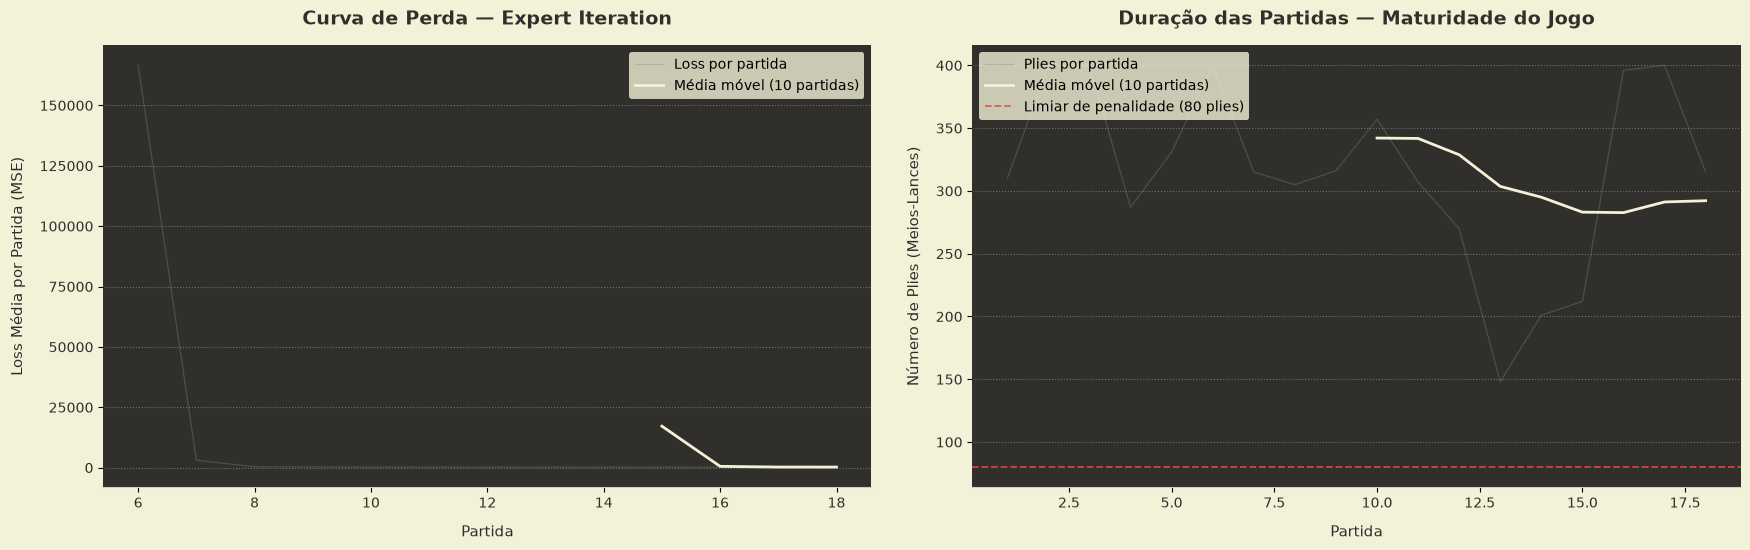

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# ── Paleta de cores — idêntica ao projeto_resnet.ipynb ────────────────────────
COR_FUNDO_EXTERNO = '#F1F2D8'   # fundo da figura (creme claro)
COR_FUNDO_INTERNO = '#312F2B'   # fundo dos eixos (escuro)
COR_LINHA_PRIM    = '#7B9459'   # verde — dados brutos (alpha baixo)
COR_LINHA_SUAVE   = '#F1F2D8'   # creme — média móvel (contraste no fundo escuro)
COR_GRID          = '#95a5a6'   # grade sutil
COR_BORDA         = '#ccd1d1'   # borda inferior do eixo


# ── Leitura dos logs do TensorBoard ───────────────────────────────────────────
def _carregar_metrica(ea, tag: str) -> tuple:
    try:
        events = ea.Scalars(tag)
        return [e.step for e in events], [e.value for e in events]
    except KeyError:
        return [], []


def carregar_logs_tensorboard(base_dir: str = "runs") -> dict:
    """
    Localiza o run mais recente em base_dir/ e carrega os escalares.
    Retorna dict vazio se nenhum run ou tensorboard não instalado.
    """
    try:
        from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
    except ImportError:
        print("[AVISO] tensorboard não instalado. Execute:  pip install tensorboard")
        return {}

    base       = Path(base_dir)
    candidates = sorted(
        list(base.glob("chess_expertiter_*")) + list(base.glob("chess_dqn_*")),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        print(f"[AVISO] Nenhum run encontrado em '{base_dir}/'.")
        return {}

    log_dir = candidates[0]
    print(f"Carregando run: {log_dir}")

    ea = EventAccumulator(str(log_dir), size_guidance={"scalars": 0})
    ea.Reload()

    tags = ea.Tags().get("scalars", [])
    data = {tag: _carregar_metrica(ea, tag) for tag in tags}
    print(f"Métricas disponíveis: {sorted(tags)}")
    return data


def moving_average(values: list, window: int) -> np.ndarray:
    if window < 2 or len(values) < window:
        return np.array(values)
    return np.convolve(values, np.ones(window) / window, mode="valid")


# ── Estilo comum — replica o padrão minimalista do projeto anterior ───────────
def _estilizar_eixo(ax, titulo: str, xlabel: str, ylabel: str):
    ax.set_facecolor(COR_FUNDO_INTERNO)
    ax.set_title(titulo,  fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
    ax.set_xlabel(xlabel, fontsize=11, labelpad=10,       color=COR_FUNDO_INTERNO)
    ax.set_ylabel(ylabel, fontsize=11, labelpad=10,       color=COR_FUNDO_INTERNO)
    ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
    ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', linestyle=':', alpha=0.6, color=COR_GRID)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color(COR_BORDA)


# ── Carrega os dados ───────────────────────────────────────────────────────────
tb_data = carregar_logs_tensorboard()

loss_steps,  loss_vals  = tb_data.get("Game/Avg_Loss",     ([], []))
plies_steps, plies_vals = tb_data.get("Game/Length_Plies", ([], []))

n = max(len(loss_vals), len(plies_vals))
SMOOTH_WINDOW = max(10, min(100, n // 20)) if n > 0 else 10
DRAW_LIMIAR   = globals().get("DRAW_PENALTY_PLIES", 80)


# ── Figura: 1 linha × 2 colunas ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)


# ── Gráfico 1: Curva de Perda ─────────────────────────────────────────────────
if loss_vals:
    ax1.plot(loss_steps, loss_vals,
             color=COR_LINHA_PRIM, linewidth=0.9, alpha=0.35,
             label='Loss por partida')
    sm = moving_average(loss_vals, SMOOTH_WINDOW)
    ax1.plot(loss_steps[len(loss_steps) - len(sm):], sm,
             color=COR_LINHA_SUAVE, linewidth=2.0,
             label=f'Média móvel ({SMOOTH_WINDOW} partidas)')
else:
    ax1.text(0.5, 0.5, 'Sem dados — execute o loop de treinamento primeiro.',
             ha='center', va='center', transform=ax1.transAxes,
             color=COR_LINHA_SUAVE, fontsize=11)

_estilizar_eixo(ax1,
    titulo  = 'Curva de Perda — Expert Iteration',
    xlabel  = 'Partida',
    ylabel  = 'Loss Média por Partida (MSE)')
ax1.legend(frameon=True, facecolor=COR_FUNDO_EXTERNO, edgecolor='none',
           fontsize=10, loc='upper right')


# ── Gráfico 2: Duração das Partidas ──────────────────────────────────────────
if plies_vals:
    ax2.plot(plies_steps, plies_vals,
             color=COR_LINHA_PRIM, linewidth=0.9, alpha=0.35,
             label='Plies por partida')
    sm_p = moving_average(plies_vals, SMOOTH_WINDOW)
    ax2.plot(plies_steps[len(plies_steps) - len(sm_p):], sm_p,
             color=COR_LINHA_SUAVE, linewidth=2.0,
             label=f'Média móvel ({SMOOTH_WINDOW} partidas)')
    ax2.axhline(DRAW_LIMIAR, color='#e74c3c', linestyle='--',
                linewidth=1.3, alpha=0.85,
                label=f'Limiar de penalidade ({DRAW_LIMIAR} plies)')
else:
    ax2.text(0.5, 0.5, 'Sem dados — execute o loop de treinamento primeiro.',
             ha='center', va='center', transform=ax2.transAxes,
             color=COR_LINHA_SUAVE, fontsize=11)

_estilizar_eixo(ax2,
    titulo  = 'Duração das Partidas — Maturidade do Jogo',
    xlabel  = 'Partida',
    ylabel  = 'Número de Plies (Meios-Lances)')
ax2.legend(frameon=True, facecolor=COR_FUNDO_EXTERNO, edgecolor='none',
           fontsize=10, loc='upper left')


plt.tight_layout(pad=2.5)
out_path = Path("training_curves_rl.png")
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor=COR_FUNDO_EXTERNO)
print(f"Figura salva em: {out_path.resolve()}")
plt.show()